<a href="https://colab.research.google.com/github/First-555/BSC_DPDM2025/blob/main/Ch5_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data

In [1]:
from sklearn.datasets import load_digits #scikit-learn

# Load the digits dataset (a modified MNIST dataset)
digits = load_digits()
X, y = digits.data, digits.target
print(f"Shape of data: {X.shape}")
print(f"Shape of target: {y.shape}")
print(f"Number of classes: {len(digits.target_names)}")
print(f"First 5 target labels: {y[:5]}")

Shape of data: (1797, 64)
Shape of target: (1797,)
Number of classes: 10
First 5 target labels: [0 1 2 3 4]


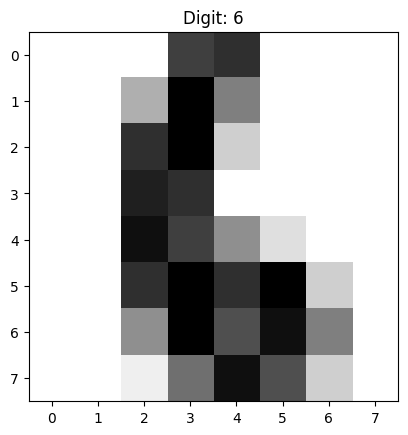

In [2]:
import matplotlib.pyplot as plt

# Get the first image and its target label
first_image = X[6]
first_label = y[6]

# Reshape the 64-feature vector to an 8x8 image
image_reshaped = first_image.reshape(8, 8)
#Display
plt.imshow(image_reshaped, cmap=plt.cm.gray_r, interpolation='nearest')
plt.title(f"Digit: {first_label}")
plt.show()

In [3]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [4]:
import pandas as pd

# Create a DataFrame for the features (pixel data)
df = pd.DataFrame(digits.data)

# Add the target (digit label) as a new column
df['target'] = digits.target

print("Dataframe created successfully with shape:", df.shape)

Dataframe created successfully with shape: (1797, 65)


In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [6]:
X.shape

(1797, 64)

In [7]:
X_train = X[:1700]
y_train = y[:1700]
X_test = X[1700:]
y_test = y[1700:]

# Model Construction
- import
- define (Hyper-parameters)
- train (Fitting)
- evaluate (วัดผล: Test and train)

## import

In [8]:
from sklearn.tree import DecisionTreeClassifier

## Define

In [9]:
tree0 = DecisionTreeClassifier(random_state=6)

## Training

In [10]:
tree0.fit(X_train,y_train)

DecisionTreeClassifier(random_state=6)

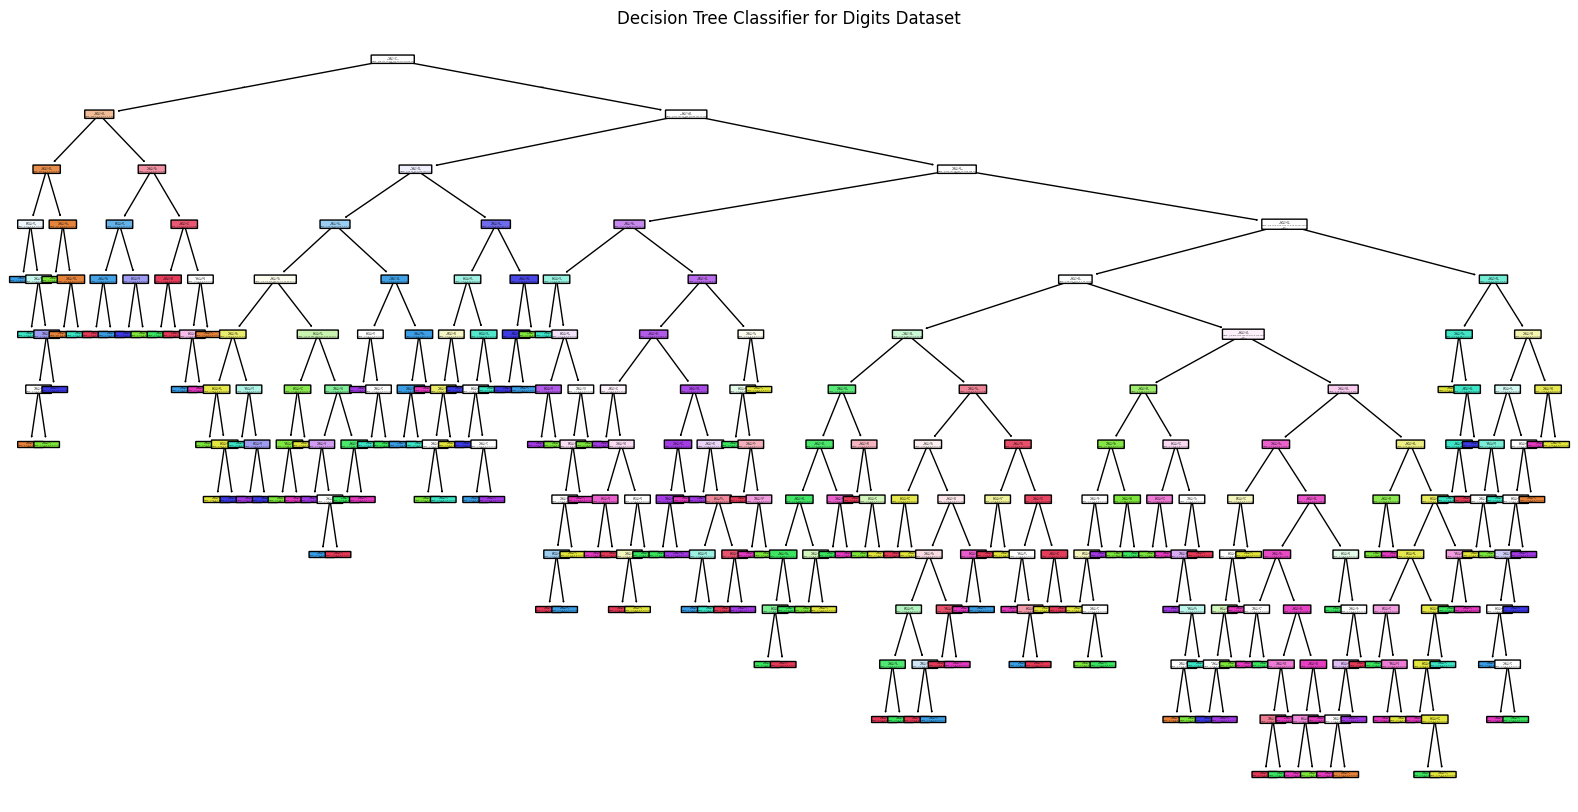

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(tree0, filled=True, rounded=True, class_names=digits.target_names.astype(str))
plt.title("Decision Tree Classifier for Digits Dataset")
plt.show()

## Evaluate

In [12]:
y_predict = tree0.predict(X_test)

In [13]:
y_predict

array([8, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 9, 5, 1, 0, 0, 6, 2, 7, 8, 2,
       0, 3, 8, 6, 8, 8, 7, 4, 3, 4, 6, 6, 6, 4, 9, 1, 9, 0, 9, 6, 7, 8,
       2, 0, 0, 6, 7, 6, 8, 2, 1, 7, 4, 6, 3, 1, 2, 9, 1, 7, 6, 8, 4, 8,
       1, 4, 0, 5, 5, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 5, 2, 2, 5, 7, 9, 4,
       4, 3, 3, 4, 9, 0, 8, 9, 8])

In [14]:
y_test

array([5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 3, 5, 1, 0, 0, 2, 2, 7, 8, 2,
       0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6, 6, 4, 9, 1, 5, 0, 9, 5, 2, 8,
       2, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4, 6, 3, 1, 3, 9, 1, 7, 6, 8, 4, 3,
       1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5,
       4, 8, 8, 4, 9, 0, 8, 9, 8])

In [15]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_predict)

0.7938144329896907

## Pre-pruning (Hyper-parameter tuning)

## Tree1

In [16]:
from sklearn.tree import DecisionTreeClassifier #import

In [17]:
tree1 = DecisionTreeClassifier(random_state=4, max_depth=3)
tree1.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=4)

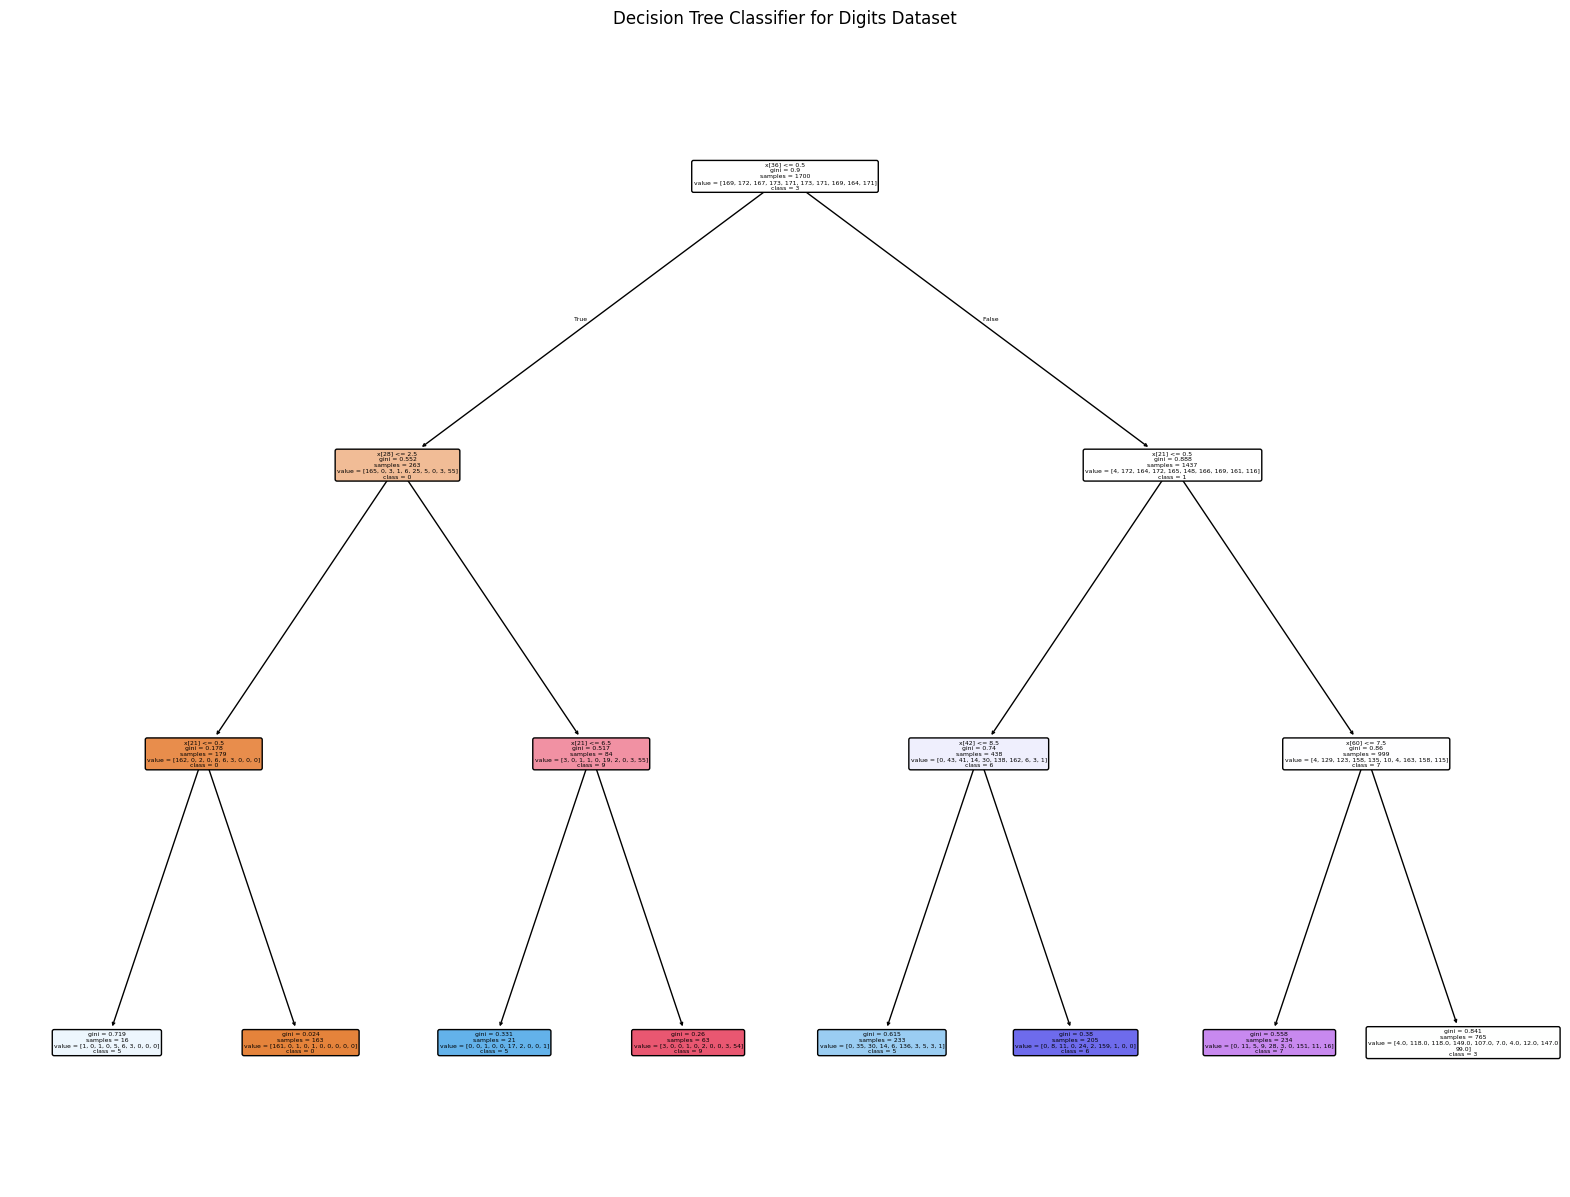

In [18]:
plt.figure(figsize=(20,15))
plot_tree(tree1, filled=True, rounded=True, class_names=digits.target_names.astype(str))
plt.title("Decision Tree Classifier for Digits Dataset")
plt.show()

## Evaluate

In [19]:
tree1 = DecisionTreeClassifier(random_state=6, max_depth=3)
tree1.fit(X_train,y_train)
y_predict = tree1.predict(X_test)
accuracy_score(y_test, y_predict)

0.4639175257731959

## Tree2

In [20]:
from sklearn.tree import DecisionTreeClassifier #import
tree2 = DecisionTreeClassifier(random_state=6, max_depth=7)
tree2.fit(X_train,y_train)
y_predict = tree2.predict(X_test)
accuracy_score(y_test, y_predict)

0.7938144329896907

## Quiz 11

In [21]:
from sklearn.tree import DecisionTreeClassifier #import
tree3 = DecisionTreeClassifier(random_state=2, max_depth=7)
tree3.fit(X_train,y_train)
y_predict = tree3.predict(X_test)
accuracy_score(y_test, y_predict)

0.8247422680412371

In [22]:
from sklearn.tree import DecisionTreeClassifier #import
tree3 = DecisionTreeClassifier(random_state=14, max_depth=7)
tree3.fit(X_train,y_train)
y_predict = tree3.predict(X_test)
accuracy_score(y_test, y_predict)

0.8041237113402062

In [23]:
best_acc = 0
best_seed = 0

for i in range(101):
    test_tree = DecisionTreeClassifier(random_state=i, max_depth=7)
    test_tree.fit(X_train, y_train)
    acc = accuracy_score(y_test, test_tree.predict(X_test))
    if acc > best_acc:
        best_acc = acc
        best_seed = i

print(f"ค่า random_state ที่ดีที่สุดคือ: {best_seed} ด้วย Accuracy: {best_acc:.4f}")

ค่า random_state ที่ดีที่สุดคือ: 2 ด้วย Accuracy: 0.8247


# Model Selection and Evaluation

1. train and test splitting which train and test have the same class distribution
2. in training data, we split it into 10-fold
3. perform cross validation and grid search (10 KNN and 10 decision trees)
4. use Accuracy as a metric
5. Evaluate the best model with test set and report

# Task
Perform a stratified train-test split on the `digits` dataset, ensuring that the training and testing sets maintain the same class distribution.

## Stratified Train-Test Split

### Subtask:
Split the data into training and testing sets while maintaining the same class distribution in both sets.


**Reasoning**:
The subtask requires splitting the data into training and testing sets while maintaining the same class distribution. The `train_test_split` function with the `stratify` parameter is the appropriate tool for this.



In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1437, 64)
Shape of X_test: (360, 64)
Shape of y_train: (1437,)
Shape of y_test: (360,)


## Define Hyperparameters and Models for Grid Search

### Subtask:
Prepare hyperparameter grids for both K-Nearest Neighbors (KNN) and Decision Tree classifiers, including a selection of 10 different configurations for each model type, to be used in the grid search as per point 3.


**Reasoning**:
The subtask requires defining hyperparameter grids for KNN and Decision Tree classifiers. I need to import `KNeighborsClassifier`, then define `knn_param_grid` and `dt_param_grid` as specified, and finally create a list of tuples combining the models and their parameter grids.



In [25]:
from sklearn.neighbors import KNeighborsClassifier

# 2. Define knn_param_grid
knn_param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19] # 10 different configurations
}

# 3. Define dt_param_grid
dt_param_grid = {
    'max_depth': [None, 2, 4, 6, 8, 10, 12, 14, 16, 18], # 10 different configurations
    'random_state': [42]
}

# 4. Create a list of tuples (model_name, model_instance, param_grid)
models_and_params = [
    ('knn', KNeighborsClassifier(), knn_param_grid),
    ('dt', DecisionTreeClassifier(), dt_param_grid)
]

print("Hyperparameter grids and models_and_params list defined successfully.")

Hyperparameter grids and models_and_params list defined successfully.


**Reasoning**:
Now that the hyperparameter grids and models are defined, the next step is to perform a grid search with cross-validation for both KNN and Decision Tree classifiers to find the best models, as per point 3 of the main task.



In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 2. Define the cross-validation strategy (10-fold CV as per point 2)
kf = 10

best_models = {}

for name, model, param_grid in models_and_params:
    print(f"Performing GridSearchCV for {name}...")
    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    print(f"Best cross-validation score for {name}: {grid_search.best_score_:.4f}")
    print("\n")

print("Grid search completed for all models.")

Performing GridSearchCV for knn...
Best parameters for knn: {'n_neighbors': 3}
Best cross-validation score for knn: 0.9896


Performing GridSearchCV for dt...
Best parameters for dt: {'max_depth': 10, 'random_state': 42}
Best cross-validation score for dt: 0.8594


Grid search completed for all models.


**Reasoning**:
The grid search has identified the best hyperparameters for both KNN and Decision Tree models. The next step, as per point 5 of the main task, is to evaluate these best models on the held-out test set and report their performance.



In [27]:
from sklearn.metrics import accuracy_score

print("Evaluating best models on the test set:")
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test accuracy for best {name} model: {accuracy:.4f}")


Evaluating best models on the test set:
Test accuracy for best knn model: 0.9861
Test accuracy for best dt model: 0.8111


## Summary:

### Data Analysis Key Findings

*   The `digits` dataset was successfully split into training and testing sets with an 80/20 ratio (1437 samples for training, 360 for testing) using a stratified sampling approach to maintain consistent class distribution.
*   Hyperparameter grids were defined for K-Nearest Neighbors (KNN) and Decision Tree classifiers, each including 10 different configurations.
*   A 10-fold cross-validation Grid Search identified the optimal hyperparameters for each model:
    *   For KNN, the best `n_neighbors` was 3, achieving a cross-validation accuracy of 0.9896.
    *   For Decision Tree, the best `max_depth` was 10 (with `random_state=42`), achieving a cross-validation accuracy of 0.8594.
*   Upon evaluation on the unseen test set, the best performing models yielded the following accuracies:
    *   KNN model (with `n_neighbors=3`): 0.9861 test accuracy.
    *   Decision Tree model (with `max_depth=10`): 0.8111 test accuracy.

### Insights or Next Steps

*   The KNN model significantly outperformed the Decision Tree model on this dataset, achieving a test accuracy of nearly 99%. This suggests that the features are well-suited for distance-based classification.
*   Further investigation could involve exploring a wider range of hyperparameters for the Decision Tree, or considering other ensemble methods (like Random Forest or Gradient Boosting) to potentially improve its performance, especially given the substantial gap with KNN.
